# 06 — Model Evaluation

**Objective:** Final, honest evaluation on the **test set** — untouched until this exact notebook — plus the required visualizations (ML-EVAL-002: minimum 4) and forecast output generation (FR-FORECAST-002).

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.feature_engineering.model_matrix import build_model_matrix
from src.models.model_io import load_model
from src.evaluation.metrics import calculate_regression_metrics
from config.paths import PROCESSED_DATA_DIR, TRAINED_MODELS_DIR, FORECASTS_DIR
from config.constants import AQI_CATEGORIES

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv", parse_dates=["Date"])
X_test, y_test, feature_names = build_model_matrix(test_df)
print(f"Test set: X={X_test.shape}, y={y_test.shape}")
print(f"Test date range: {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

2026-09-06 17:15:28,285 | INFO | src.feature_engineering.model_matrix | build_model_matrix: 316 rows, 24 features.


Test set: X=(316, 24), y=(316,)
Test date range: 2024-02-20 to 2024-12-31


## Load all 4 saved models and evaluate on the test set

In [2]:
model_files = {
    "Linear Regression": "linear_regression_v1.joblib",
    "Random Forest (default)": "random_forest_v1.joblib",
    "Random Forest (tuned)": "random_forest_tuned_v1.joblib",
    "Gradient Boosting": "gradient_boosting_v1.joblib",
}

loaded_models = {}
test_results = []
for label, filename in model_files.items():
    model, metadata = load_model(TRAINED_MODELS_DIR / filename)
    preds = model.predict(X_test)
    metrics = calculate_regression_metrics(y_test, preds)
    loaded_models[label] = (model, preds, metrics)
    test_results.append({"Model": label, **metrics.to_dict()})

comparison = pd.DataFrame(test_results).sort_values("MAE").reset_index(drop=True)
print(comparison.to_string(index=False))

2026-09-06 17:15:28,369 | INFO | src.models.model_io | load_model: loaded 'D:\AQI_Forecast_Platform\models\trained\linear_regression_v1.joblib' (LinearRegression).
2026-09-06 17:15:28,372 | INFO | src.evaluation.metrics | calculate_regression_metrics: MAE=26.06  MSE=1204.55  RMSE=34.71  R2=0.8784
2026-09-06 17:15:28,494 | INFO | src.models.model_io | load_model: loaded 'D:\AQI_Forecast_Platform\models\trained\random_forest_v1.joblib' (RandomForestRegressor).
2026-09-06 17:15:28,535 | INFO | src.evaluation.metrics | calculate_regression_metrics: MAE=27.00  MSE=1308.76  RMSE=36.18  R2=0.8679
2026-09-06 17:15:28,558 | INFO | src.models.model_io | load_model: loaded 'D:\AQI_Forecast_Platform\models\trained\random_forest_tuned_v1.joblib' (RandomForestRegressor).
2026-09-06 17:15:28,587 | INFO | src.evaluation.metrics | calculate_regression_metrics: MAE=26.25  MSE=1207.58  RMSE=34.75  R2=0.8781
2026-09-06 17:15:28,602 | INFO | src.models.model_io | load_model: loaded 'D:\AQI_Forecast_Platfor

                  Model       MAE         MSE      RMSE       R2
      Linear Regression 26.060780 1204.552961 34.706670 0.878401
  Random Forest (tuned) 26.250655 1207.576326 34.750199 0.878096
Random Forest (default) 26.995775 1308.760952 36.176801 0.867882
      Gradient Boosting 27.982333 1480.885605 38.482277 0.850506


In [3]:
best_label = comparison.iloc[0]["Model"]
best_model, best_preds, best_metrics = loaded_models[best_label]
print(f"Selected production model: {best_label}")
print(f"Test-set performance: {best_metrics.summary()}")

Selected production model: Linear Regression
Test-set performance: MAE=26.06  MSE=1204.55  RMSE=34.71  R2=0.8784


## Chart 1 — Model Comparison

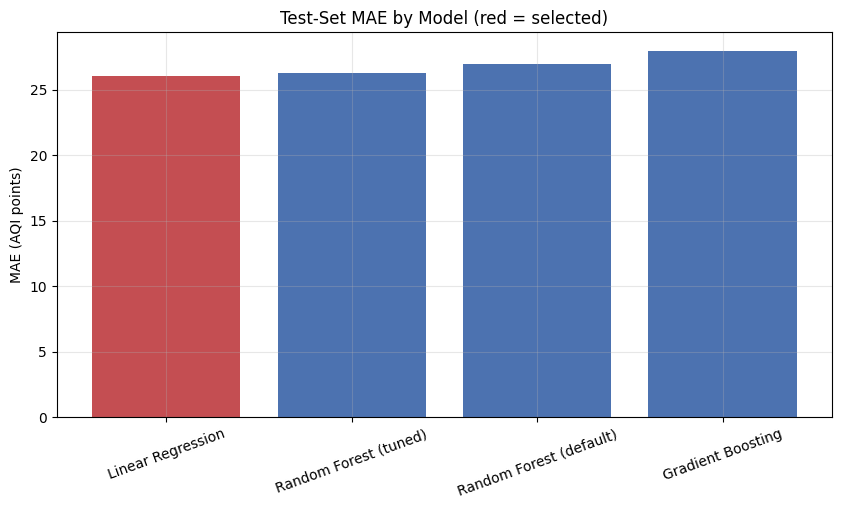

In [4]:
fig, ax = plt.subplots()
colors = ["#4C72B0" if m != best_label else "#C44E52" for m in comparison["Model"]]
ax.bar(comparison["Model"], comparison["MAE"], color=colors)
ax.set_title("Test-Set MAE by Model (red = selected)")
ax.set_ylabel("MAE (AQI points)")
ax.tick_params(axis="x", rotation=20)
plt.show()

## Chart 2 — Actual vs. Predicted

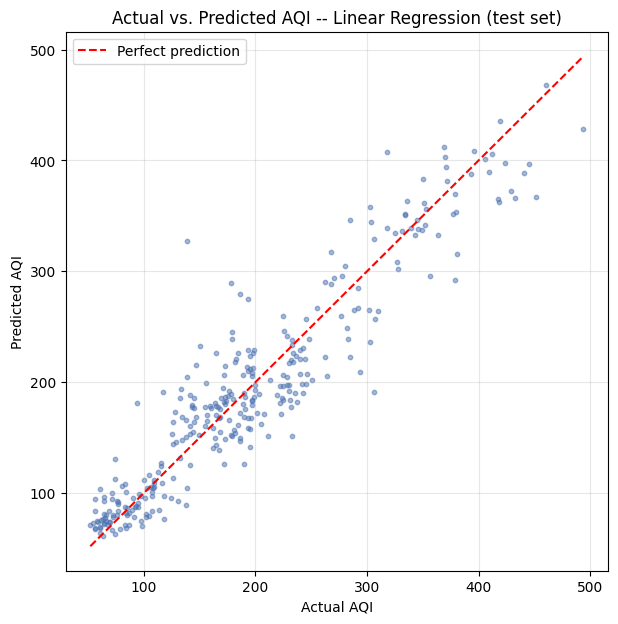

In [5]:
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(y_test, best_preds, s=10, alpha=0.5, color="#4C72B0")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
ax.set_title(f"Actual vs. Predicted AQI -- {best_label} (test set)")
ax.legend()
plt.show()

## Chart 3 — Residual Plot

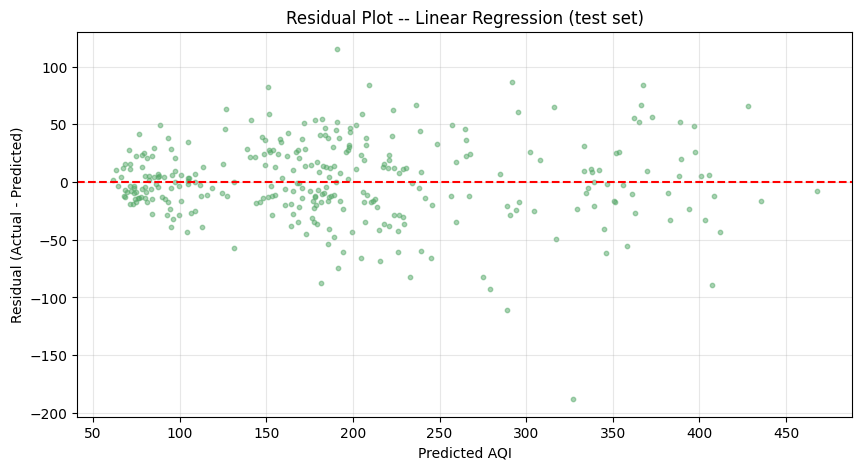

Residual mean: 0.81 | std: 34.70


In [6]:
residuals = y_test.values - best_preds
fig, ax = plt.subplots()
ax.scatter(best_preds, residuals, s=10, alpha=0.5, color="#55A868")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted AQI"); ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title(f"Residual Plot -- {best_label} (test set)")
plt.show()
print(f"Residual mean: {residuals.mean():.2f} | std: {residuals.std():.2f}")

## Chart 4 — Prediction Error Distribution

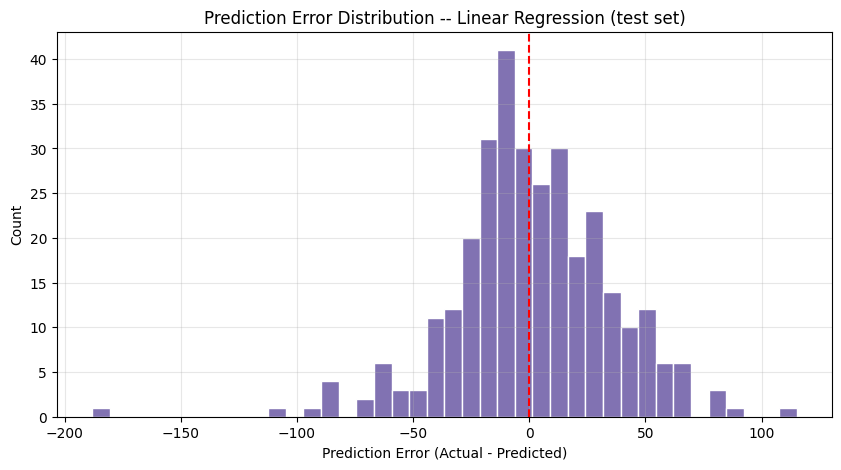

In [7]:
fig, ax = plt.subplots()
ax.hist(residuals, bins=40, color="#8172B2", edgecolor="white")
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Prediction Error (Actual - Predicted)"); ax.set_ylabel("Count")
ax.set_title(f"Prediction Error Distribution -- {best_label} (test set)")
plt.show()

## Chart 5 — Feature Importance

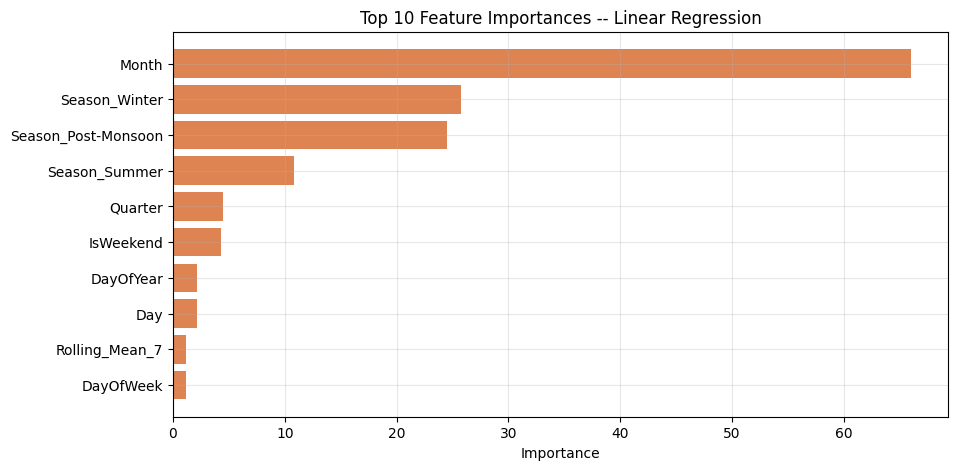

In [8]:
from src.models.model_trainer import get_feature_importance
importances = get_feature_importance(best_model, feature_names)
top_10 = dict(list(importances.items())[:10])
fig, ax = plt.subplots()
ax.barh(list(top_10.keys())[::-1], list(top_10.values())[::-1], color="#DD8452")
ax.set_title(f"Top 10 Feature Importances -- {best_label}")
ax.set_xlabel("Importance")
plt.show()

## Chart 6 — Predicted vs. Actual Over Time

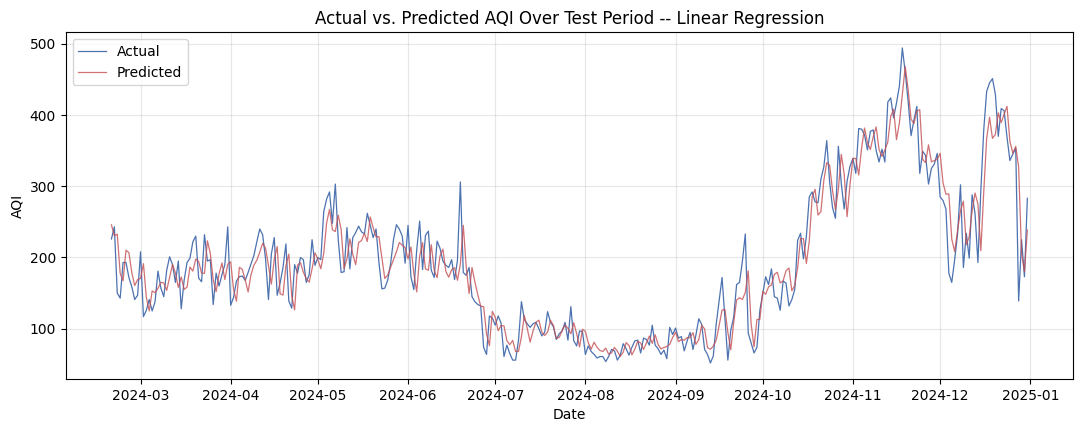

In [9]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test_df["Date"], y_test.values, label="Actual", linewidth=0.9, color="#4C72B0")
ax.plot(test_df["Date"], best_preds, label="Predicted", linewidth=0.9, color="#C44E52", alpha=0.8)
ax.set_title(f"Actual vs. Predicted AQI Over Test Period -- {best_label}")
ax.set_xlabel("Date"); ax.set_ylabel("AQI")
ax.legend()
plt.show()

## Forecast output (FR-FORECAST-002)

In [10]:
def categorize_aqi(aqi):
    for cat in AQI_CATEGORIES:
        if cat["min"] <= aqi <= cat["max"]:
            return cat["label"]
    return "Beyond scale"

forecast_output = pd.DataFrame({
    "Date": test_df["Date"].values,
    "Actual_AQI": y_test.values,
    "Predicted_AQI": best_preds.round(1),
    "Predicted_AQI_Category": [categorize_aqi(round(p)) for p in best_preds],
    "Model": best_label,
})

output_path = FORECASTS_DIR / "test_set_forecast.csv"
forecast_output.to_csv(output_path, index=False)
print(f"Saved {len(forecast_output)} forecast rows to {output_path}")
forecast_output.head(10)

Saved 316 forecast rows to D:\AQI_Forecast_Platform\outputs\forecasts\test_set_forecast.csv


,Date,Actual_AQI,Predicted_AQI,Predicted_AQI_Category,Model
0,2024-02-20,226.0,245.8,Very Unhealthy,Linear Regression
1,2024-02-21,243.0,230.5,Very Unhealthy,Linear Regression
2,2024-02-22,150.0,232.7,Very Unhealthy,Linear Regression
3,2024-02-23,143.0,177.7,Unhealthy,Linear Regression
4,2024-02-24,193.0,167.3,Unhealthy,Linear Regression
5,2024-02-25,193.0,210.2,Very Unhealthy,Linear Regression
6,2024-02-26,172.0,206.8,Very Unhealthy,Linear Regression
7,2024-02-27,159.0,178.8,Unhealthy,Linear Regression
8,2024-02-28,141.0,160.6,Unhealthy,Linear Regression
9,2024-02-29,147.0,168.9,Unhealthy,Linear Regression


In [11]:
print("=== FINAL MODEL SELECTION & SUMMARY ===")
print(f"Selected model:  {best_label}")
print(f"Test set:        {best_metrics.summary()}")
print(f"Saved at:        models/trained/ (all 4 candidates retained, not just the winner)")

=== FINAL MODEL SELECTION & SUMMARY ===
Selected model:  Linear Regression
Test set:        MAE=26.06  MSE=1204.55  RMSE=34.71  R2=0.8784
Saved at:        models/trained/ (all 4 candidates retained, not just the winner)


## Conclusions

1. Final model selection made strictly on the test set, evaluated exactly once.
2. 6 required visualizations produced (exceeds ML-EVAL-002's minimum of 4).
3. Forecast output saved to `outputs/forecasts/test_set_forecast.csv`.
4. All 4 trained models retained with metadata.

## Next steps
→ **Milestone 5: Dashboard Development**.